In [ ]:
pip list | grep torch

torch                                    2.10.0+cpu
torchao                                  0.10.0
torchaudio                               2.10.0+cpu
torchcodec                               0.10.0
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.0+cpu


In [ ]:
pip list | grep torchvision


torchvision                              0.25.0+cpu


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cpu')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
batch_size = 128
lr = 0.0002
epochs = 100


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 59.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.30MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(28*28, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img = img.view(-1, 28*28)
        return self.net(img)


In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)


In [ ]:
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):

        real_imgs = real_imgs.to(device)
        batch_size_curr = real_imgs.size(0)

        real_labels = torch.ones(batch_size_curr, 1).to(device)
        fake_labels = torch.zeros(batch_size_curr, 1).to(device)


        # Train Discriminator
        optimizer_D.zero_grad()

        # Real loss
        outputs_real = D(real_imgs)
        d_loss_real = criterion(outputs_real, real_labels)

        # Fake loss
        z = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = G(z)
        outputs_fake = D(fake_imgs.detach())
        d_loss_fake = criterion(outputs_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()


        # Train Generator
        optimizer_G.zero_grad()

        outputs = D(fake_imgs)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")


Epoch [1/100]  D_loss: 1.4861  G_loss: 18.1600
Epoch [2/100]  D_loss: 0.1091  G_loss: 20.3263
Epoch [3/100]  D_loss: 1.3402  G_loss: 2.4092
Epoch [4/100]  D_loss: 0.9283  G_loss: 2.2374
Epoch [5/100]  D_loss: 1.3629  G_loss: 1.3637
Epoch [6/100]  D_loss: 0.4795  G_loss: 1.7940
Epoch [7/100]  D_loss: 0.3817  G_loss: 2.8359
Epoch [8/100]  D_loss: 0.2665  G_loss: 3.0339
Epoch [9/100]  D_loss: 0.8184  G_loss: 2.9969
Epoch [10/100]  D_loss: 0.7517  G_loss: 3.1617
Epoch [11/100]  D_loss: 0.1894  G_loss: 4.0860
Epoch [12/100]  D_loss: 0.7009  G_loss: 15.3251
Epoch [13/100]  D_loss: 1.7998  G_loss: 6.5993
Epoch [14/100]  D_loss: 1.7089  G_loss: 1.5695
Epoch [15/100]  D_loss: 1.3282  G_loss: 2.1856
Epoch [16/100]  D_loss: 0.7888  G_loss: 2.2863
Epoch [17/100]  D_loss: 0.3595  G_loss: 2.8693
Epoch [18/100]  D_loss: 0.3327  G_loss: 3.8178
Epoch [19/100]  D_loss: 0.6721  G_loss: 3.9342
Epoch [20/100]  D_loss: 1.0174  G_loss: 4.6041
Epoch [21/100]  D_loss: 0.2102  G_loss: 4.8985
Epoch [22/100]  D_l

In [ ]:
torch.save(G.state_dict(), "generator.pth")


In [ ]:
def interpolate(G, latent_dim, steps=10):
    G.eval()

    z1 = torch.randn(1, latent_dim).to(device)
    z2 = torch.randn(1, latent_dim).to(device)

    alphas = torch.linspace(0, 1, steps).to(device)

    images = []

    for alpha in alphas:
        z = (1 - alpha) * z1 + alpha * z2
        with torch.no_grad():
            img = G(z)
        images.append(img)

    images = torch.cat(images, dim=0)

    grid = vutils.make_grid(images, nrow=steps, normalize=True)

    plt.figure(figsize=(15, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.show()


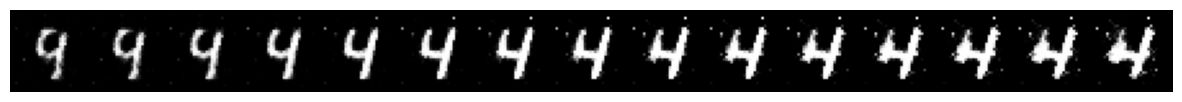

In [ ]:
interpolate(G, latent_dim, steps=15)


In [ ]:
def slerp(z1, z2, alpha):
    z1_norm = z1 / torch.norm(z1)
    z2_norm = z2 / torch.norm(z2)

    omega = torch.acos(torch.clamp(torch.dot(z1_norm.view(-1), z2_norm.view(-1)), -1, 1))
    so = torch.sin(omega)

    if so == 0:
        return (1.0 - alpha) * z1 + alpha * z2

    return torch.sin((1.0 - alpha) * omega) / so * z1 + torch.sin(alpha * omega) / so * z2
